In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_transactions = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df_transactions['InvoiceDate'] = pd.to_datetime(df_transactions['InvoiceDate'])
print(df_transactions.shape)
print(df_transactions.head(3))

(541910, 8)
  Invoice StockCode                         Description  Quantity  \
0  536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                 WHITE METAL LANTERN         6   
2  536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  


In [4]:
df_transactions['TotalSales'] = df_transactions['Quantity'] * df_transactions['Price']

total_sales = df_transactions['TotalSales'].sum()
print(f'Total sales revenue: {total_sales:,.2f}')

n_customers = df_transactions['Customer ID'].nunique()
print('Number of unique customers:', n_customers)

Total sales revenue: 9,747,765.93
Number of unique customers: 4372


In [5]:
np.random.seed(42)

categories = ['Electronics', 'Clothing', 'Home', 'Sports', 'Beauty']
product_ids = list(range(1001, 1101))
product_categories = np.random.choice(categories, 100)
product_prices = np.round(np.random.uniform(5, 500, 100), 2)

df_products = pd.DataFrame({
    'ProductID': product_ids, 
    'Category': product_categories, 
    'Price': product_prices
})

df_orders = pd.DataFrame({
    'OrderID': range(2001, 3001),
    'CustomerID': np.random.randint(1, 200, 1000),
    'ProductID': np.random.choice(product_ids, 1000),
    'Quantity': np.random.randint(1, 10, 1000),
    'OrderDate': pd.date_range(start='2023-01-01', periods=1000, freq='h') 
})

print(df_products.shape)
print(df_orders.shape)

(100, 3)
(1000, 5)


In [6]:
print(df_transactions.head(3))
display(df_transactions.head(3))

  Invoice StockCode                         Description  Quantity  \
0  536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                 WHITE METAL LANTERN         6   
2  536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

          InvoiceDate  Price  Customer ID         Country  TotalSales  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom       22.00  


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [7]:
df_merged = pd.merge(df_orders, df_products, on='ProductID')

df_merged['OrderValue'] = df_merged['Quantity'] * df_merged['Price']

category_sales = df_merged.groupby('Category')['OrderValue'].sum().sort_values(ascending=False)
display(category_sales.to_frame(name='Total Revenue ($)'))

category_share = (category_sales / category_sales.sum()) * 100
display(category_share.to_frame(name='Revenue Share (%)'))

,Total Revenue ($)
Category,
Sports,295906.30
Beauty,269329.85
Clothing,247582.59
Electronics,220048.98
Home,212167.02


,Revenue Share (%)
Category,
Sports,23.766911
Beauty,21.632316
Clothing,19.885597
Electronics,17.674124
Home,17.041052


In [8]:
customer_spend = df_merged.groupby('CustomerID')['OrderValue'].sum()

avg_customer_spend = customer_spend.mean()
print(f'Average Customer Spend: ${avg_customer_spend:,.2f}')

top_customers = customer_spend.sort_values(ascending=False).head(3)
display(top_customers.to_frame(name='Top 3 VIP Spend ($)'))

segments = pd.qcut(customer_spend, q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
display(segments.value_counts().to_frame(name='Number of Customers'))

Average Customer Spend: $6,319.97


,Top 3 VIP Spend ($)
CustomerID,
104,17498.75
113,15953.12
145,15021.70


,Number of Customers
OrderValue,
Low,50
Mid-Low,49
Mid-High,49
High,49


In [10]:
df_merged['Month'] = df_merged['OrderDate'].dt.month
monthly_sales = df_merged.groupby('Month')['OrderValue'].sum()

daily_sales = daily_sales.sort_index()
moving_average = daily_sales.rolling(window=7).mean()

In [11]:
from itertools import combinations

baskets = [list(np.random.choice(['Milk', 'Bread', 'Eggs', 'Butter', 'Cheese', 'Apples', 'Bananas'], 3, replace=False)) for _ in range(300)]
df_baskets = pd.DataFrame({'TransactionID': np.repeat(range(300), 3), 'Product': [item for basket in baskets for item in basket]})

product_counts = df_baskets['Product'].value_counts()
display(product_counts.to_frame(name='Most Common Items'))

pair_counts = {}
for basket in baskets:
    pairs = combinations(sorted(basket), 2)
    for pair in pairs:
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

top_pairs = sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)
display(pd.DataFrame(top_pairs[:5], columns=['Product Pair', 'Frequency']))

,Most Common Items
Product,
Bread,139
Butter,138
Eggs,131
Apples,129
Bananas,129
Milk,117
Cheese,117


,Product Pair,Frequency
0,"(Butter, Eggs)",54
1,"(Bananas, Butter)",52
2,"(Apples, Bread)",51
3,"(Bread, Milk)",48
4,"(Bread, Eggs)",47


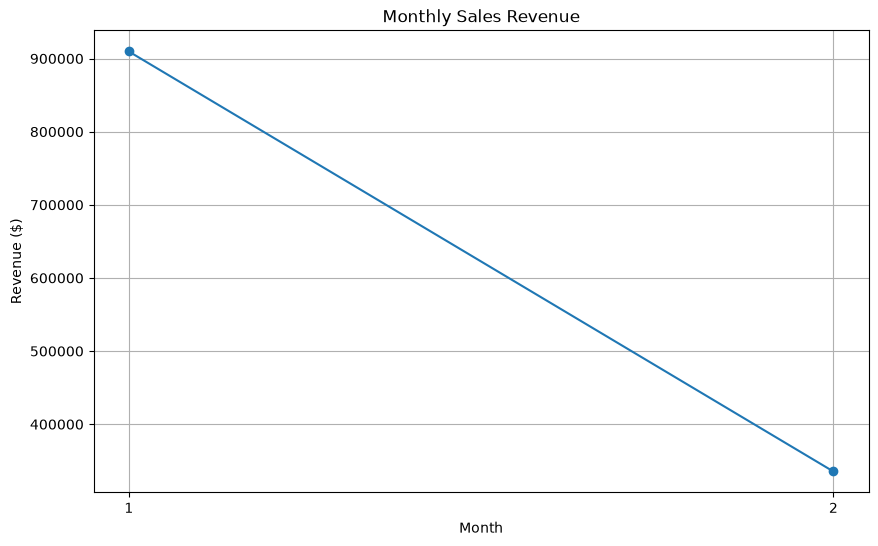

In [12]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.xticks(monthly_sales.index)
plt.show()

In [13]:
top_category = category_sales.index[0]
top_category_revenue = category_sales.iloc[0]

print("\n--- BUSINESS RECOMMENDATION ---")
print(f"The highest generating category is '{top_category}' with ${top_category_revenue:,.2f} in sales.")
print(f"Recommendation: Prioritize marketing and inventory stocking for the {top_category} line.")


--- BUSINESS RECOMMENDATION ---
The highest generating category is 'Sports' with $295,906.30 in sales.
Recommendation: Prioritize marketing and inventory stocking for the Sports line.


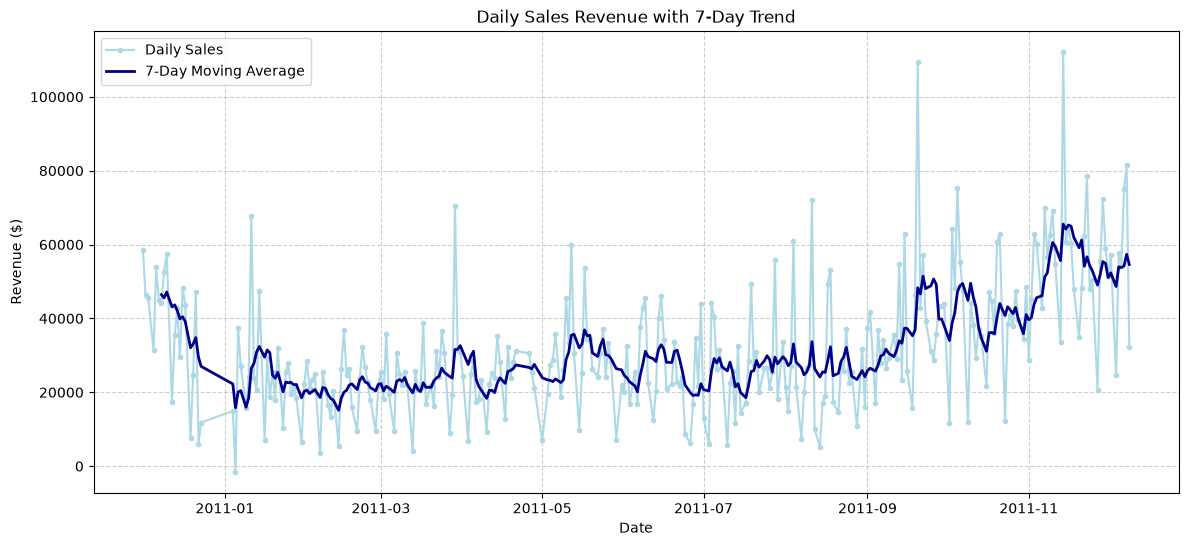

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(daily_sales.index, daily_sales.values, label='Daily Sales', color='lightblue', marker='.')
plt.plot(moving_average.index, moving_average.values, label='7-Day Moving Average', color='darkblue', linewidth=2)
plt.title('Daily Sales Revenue with 7-Day Trend')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
df_cleaned = df_transactions.dropna(subset=['Customer ID'])
unique_customers_cleaned = df_cleaned['Customer ID'].nunique()
print(f"Unique customers after cleaning: {unique_customers_cleaned}")

highest_spender = customer_spend.idxmax()
highest_spend_amount = customer_spend.max()
print(f"Highest Spending Customer ID: {highest_spender} (${highest_spend_amount:,.2f})")

lowest_spender = customer_spend.idxmin()
lowest_spend_amount = customer_spend.min()
print(f"Lowest Spending Customer ID: {lowest_spender} (${lowest_spend_amount:,.2f})")

Unique customers after cleaning: 4372
Highest Spending Customer ID: 104 ($17,498.75)
Lowest Spending Customer ID: 199 ($261.72)
